<a href="https://colab.research.google.com/github/guebin/DL2026/blob/master/posts/11wk.ipynb"><img src="https://colab.research.google.com/assets/colab-badge.svg" style="text-align: left"></a>

# 1. 강의영상

In [1]:
# {{<video https://youtu.be/playlist?list=PLQqh36zP38-xB7p8AzMKUrEfxL0Vte-pY&si=BwVUNxT8IIPrjIcA>}}

# 2. Imports

In [2]:
import torch
import torchvision
import matplotlib.pyplot as plt

In [3]:
plt.rcParams['figure.figsize'] = (4.5, 3.0)

# 3. 다항분류

## A. 범주형자료의 변환 

`-` 범주형자료를 숫자로 어떻게 바꿀까? 

- 실패 / 성공 $\to$ 0 / 1
- 숫자0그림 / 숫자1그림 $\to$ 0 / 1 
- 강아지그림 / 고양이그림 $\to$ 0 / 1
- 강아지그림 / 고양이그림 / 토끼그림 $\to$ 0 / 1 / 2 ?????

`-` 주입식교육

- 잘못된방식: 강아지그림 = 0, 고양이그림 = 1, 토끼그림 = 2
- 올바른방식: 강아지그림 = [1,0,0], 고양이그림 = [0,1,0], 토끼그림 = [0,0,1]  ### <-- 이런방식을 원핫인코딩이라함

`-` 왜? 

- 설명1: 강아지그림, 고양이그림,  토끼그림은 서열척도가 아니라 명목척도임. 그래서 범주를 0,1,2으로 숫자화하면 평균등의 의미가 없음 (사회조사분석사 2급 스타일) 
- 설명2: 범주형은 원핫인코딩으로 해야함 ("30일만에 끝내는 실전머신러닝" 이런 책에 나오는 스타일) 
- 설명3: 동전을 한번 던져서 나오는 결과는 베르누이분포, 즉 시행횟수=1인 이항분포 $B(1,p)$를 따름. 주사위 한번 던져서 나오는 눈금의 숫자는 시행횟수=1인 다항분포 $M(1,{\bf p})$를 따름. 시행횟수=1인 이항분포의 실현값은 0,1 이고, 시행횟수=1인 다항분포의 실현값은 [1,0,0], [0,1,0], [0,0,1] 이므로 당연히 $y_i$ 는 [1,0,0], [0,1,0], [0,0,1] 중 하나의 형태를 가진다고 가정하는게 바람직함

## B. 실습: 3개의 클래스를 구분

`-` 데이터준비 

In [8]:
train_dataset = torchvision.datasets.MNIST(root='./data',train=True,download=True)
to_tensor = torchvision.transforms.ToTensor()
X3 = torch.stack([to_tensor(Xi) for Xi, yi in train_dataset if yi==3])
X7 = torch.stack([to_tensor(Xi) for Xi, yi in train_dataset if yi==7])
X9 = torch.stack([to_tensor(Xi) for Xi, yi in train_dataset if yi==9])
X = torch.concat([X3,X7,X9]).reshape(-1,1*28*28)
y = torch.tensor([0]*6131 + [1]*6265+ [2]*len(X9))

In [9]:
print(X.shape)
print(y.shape)

torch.Size([18345, 784])
torch.Size([18345])


In [10]:
y

tensor([0, 0, 0,  ..., 2, 2, 2])

In [11]:
Y = torch.nn.functional.one_hot(y).float()
Y

tensor([[1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        ...,
        [0., 0., 1.],
        [0., 0., 1.],
        [0., 0., 1.]])

`-` 적합 

In [21]:
torch.manual_seed(43052)
net = torch.nn.Sequential(
    torch.nn.Linear(784,32),
    torch.nn.ReLU(),
    torch.nn.Linear(32,3),
)
loss_fn = torch.nn.CrossEntropyLoss() # 의미상 CEWithLogitsLoss
optimizr = torch.optim.Adam(net.parameters())
for epoc in range(1,31):
    #1
    netout = net(X) # netout: (n,3) 
    #2
    loss = loss_fn(netout,Y) 
    #3
    loss.backward()
    #4 
    optimizr.step()
    optimizr.zero_grad()

In [22]:
(netout.argmax(axis=1) == Y.argmax(axis=1)).float().mean()

tensor(0.9270)

`-` 그런데 사실.. 이렇게 해도된다. (`y`를 써서..)

In [23]:
torch.manual_seed(43052)
net = torch.nn.Sequential(
    torch.nn.Linear(784,32),
    torch.nn.ReLU(),
    torch.nn.Linear(32,3),
)
loss_fn = torch.nn.CrossEntropyLoss() # 의미상 CEWithLogitsLoss
optimizr = torch.optim.Adam(net.parameters())
for epoc in range(1,31):
    #1
    netout = net(X) # netout: (n,3) 
    #2
    loss = loss_fn(netout,y) 
    #3
    loss.backward()
    #4 
    optimizr.step()
    optimizr.zero_grad()

In [24]:
(netout.argmax(axis=1) == Y.argmax(axis=1)).float().mean()

tensor(0.9270)

> 파이토치의 친절함 

## C. 결론

`-` 조금 헷갈리지만..

|task | 오차항의가정 | 마지막활성화함수| netout의 의미 | 손실함수(파이토치) | 손실함수(개념)
|:--:|:--:|:--:|:--:|:--:|:--:|
|이항분류 | 시행횟수=1인 이항분포 | Sigmoid | prob | `BCELoss` | BCE | 
|이항분류 | 시행횟수=1인 이항분포 | None | logit | `BCEWithLogitsLoss` | NA | 
|다항분류 | 시행횟수=1인 다항분포 | Softmax |  probs |  NA | CE | 
|다항분류 | 시행횟수=1인 다항분포 | Noen | logits |  `CrossEntropyLoss` | NA | 

# 4. CNN 미리보기

## A. 그 유명한 CNN

`-` <https://brunch.co.kr/@hvnpoet/46>

`-` <https://brunch.co.kr/@hvnpoet/109> 

## B. 짧은코드

*Fashion MNIST*

In [64]:
train_dataset = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True)
test_dataset = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True)
train_dataset = torch.utils.data.Subset(train_dataset, range(5000))
test_dataset = torch.utils.data.Subset(test_dataset, range(1000))
to_tensor = torchvision.transforms.ToTensor()
X = torch.stack([to_tensor(img) for img, lbl in train_dataset])
y = torch.tensor([lbl for img, lbl in train_dataset])
XX = torch.stack([to_tensor(img) for img, lbl in test_dataset])
yy = torch.tensor([lbl for img, lbl in test_dataset])

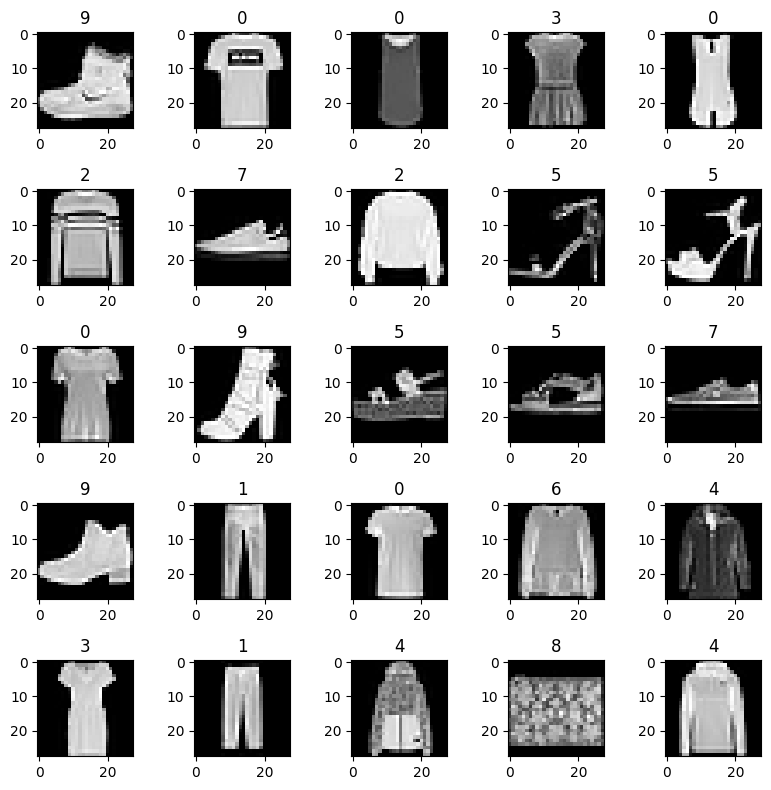

In [65]:
fig,ax = plt.subplots(5,5,figsize=(8,8))
for i in range(5):
    for j in range(5):
        ax[i][j].imshow(X[5*i+j].reshape(28,28),cmap="gray")
        ax[i][j].set_title(y[5*i+j].item())
fig.tight_layout() 

*좋은거 알려줄게요*

In [136]:
X.shape

torch.Size([5000, 1, 28, 28])

In [137]:
flatten = torch.nn.Flatten()

In [138]:
flatten(X).shape

torch.Size([5000, 784])

*첫시도*

In [227]:
X = X.to("cuda:0")
y = y.to("cuda:0")

In [233]:
torch.manual_seed(0)
net = torch.nn.Sequential(
    torch.nn.Flatten(),
    torch.nn.Linear(784,32),
    torch.nn.ReLU(),
    torch.nn.Linear(32,10)
).to("cuda:0")
loss_fn = torch.nn.CrossEntropyLoss()
optimizr = torch.optim.Adam(net.parameters())

In [234]:
for epoc in range(1,500):
    #1
    logits = net(X)
    #2
    loss = loss_fn(logits, y) 
    #3
    loss.backward()
    #4 
    optimizr.step()
    optimizr.zero_grad()

In [235]:
(net(X).argmax(axis=1) == y).float().mean()

tensor(0.9402, device='cuda:0')

In [236]:
net.to("cpu")

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=32, bias=True)
  (2): ReLU()
  (3): Linear(in_features=32, out_features=10, bias=True)
)

In [237]:
(net(XX).argmax(axis=1) == yy).float().mean()

tensor(0.8350)

*발악수준으로 설계한 신경망*

In [287]:
X = X.to("cuda:0")
y = y.to("cuda:0")

In [294]:
torch.manual_seed(0)
net = torch.nn.Sequential(
    torch.nn.Flatten(),
    torch.nn.Linear(784,256),
    torch.nn.Dropout(0.7), #0.5->0.9->0.7
    torch.nn.ReLU(),
    torch.nn.Linear(256,256),
    torch.nn.Dropout(0.7),
    torch.nn.ReLU(),
    torch.nn.Linear(256,256),
    torch.nn.Dropout(0.7),
    torch.nn.ReLU(),    
    torch.nn.Linear(256,10)
).to("cuda:0")
loss_fn = torch.nn.CrossEntropyLoss()
optimizr = torch.optim.Adam(net.parameters())

In [295]:
for epoc in range(1,5000):
    #1
    logits = net(X)
    #2
    loss = loss_fn(logits, y) 
    #3
    loss.backward()
    #4 
    optimizr.step()
    optimizr.zero_grad()

In [296]:
net.eval()

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=256, bias=True)
  (2): Dropout(p=0.7, inplace=False)
  (3): ReLU()
  (4): Linear(in_features=256, out_features=256, bias=True)
  (5): Dropout(p=0.7, inplace=False)
  (6): ReLU()
  (7): Linear(in_features=256, out_features=256, bias=True)
  (8): Dropout(p=0.7, inplace=False)
  (9): ReLU()
  (10): Linear(in_features=256, out_features=10, bias=True)
)

In [297]:
(net(X).argmax(axis=1) == y).float().mean()

tensor(0.9966, device='cuda:0')

In [298]:
net.to("cpu")

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=256, bias=True)
  (2): Dropout(p=0.7, inplace=False)
  (3): ReLU()
  (4): Linear(in_features=256, out_features=256, bias=True)
  (5): Dropout(p=0.7, inplace=False)
  (6): ReLU()
  (7): Linear(in_features=256, out_features=256, bias=True)
  (8): Dropout(p=0.7, inplace=False)
  (9): ReLU()
  (10): Linear(in_features=256, out_features=10, bias=True)
)

In [299]:
(net(XX).argmax(axis=1) == yy).float().mean()

tensor(0.8490)

- 통곡의벽 85%

*대충대충 설계한 합성곱신경망*

In [540]:
torch.manual_seed(0)
net = torch.nn.Sequential(
    torch.nn.Conv2d(1,16,2),
    torch.nn.ReLU(),    
    torch.nn.MaxPool2d(3),
    torch.nn.Flatten(),
    torch.nn.Linear(1296,10),
).to("cuda")
loss_fn = torch.nn.CrossEntropyLoss()
optimizr = torch.optim.Adam(net.parameters())

In [541]:
for epoc in range(1,500):
    #1
    logits = net(X)
    #2
    loss = loss_fn(logits, y) 
    #3
    loss.backward()
    #4 
    optimizr.step()
    optimizr.zero_grad()

In [542]:
(net(X).argmax(axis=1) == y).float().mean()
net.to("cpu")
(net(XX).argmax(axis=1) == yy).float().mean()

tensor(0.8750)

## C. 심지어 파라메터가 적음

In [152]:
net1 = torch.nn.Sequential(
    torch.nn.Flatten(),
    torch.nn.Linear(784,2048),
    torch.nn.ReLU(),
    torch.nn.Linear(2048,10)
)
net2 = torch.nn.Sequential(
    torch.nn.Conv2d(1,16,2),
    torch.nn.ReLU(),
    torch.nn.MaxPool2d(2),
    torch.nn.Flatten(),
    torch.nn.Linear(2704,10),
)

In [153]:
net1_params = list(net1.parameters())
print(net1_params[0].shape)
print(net1_params[1].shape)
print(net1_params[2].shape)
print(net1_params[3].shape)

torch.Size([2048, 784])
torch.Size([2048])
torch.Size([10, 2048])
torch.Size([10])


In [154]:
2048*784 + 2048 + 10*2048 + 10 

1628170

In [155]:
net2_params = list(net2.parameters())
print(net2_params[0].shape)
print(net2_params[1].shape)
print(net2_params[2].shape)
print(net2_params[3].shape)

torch.Size([16, 1, 2, 2])
torch.Size([16])
torch.Size([10, 2704])
torch.Size([10])


In [156]:
16*1*2*2 + 16 + 10*2704 + 10 

27130

In [157]:
27130/1628170

0.01666287918337766

# 5. CNN 핵심레이어 

## A. `torch.nn.ReLU`

**(예시1) 연산방법**

In [158]:
img = torch.randn(1,1,4,4) # (4,4) 흑백이미지 한장
relu = torch.nn.ReLU()

In [159]:
img

tensor([[[[ 1.4381,  0.2449, -0.6420,  2.6874],
          [ 0.7790,  1.0558,  0.7939,  0.1099],
          [ 0.3492,  1.7610,  1.6032,  2.4212],
          [ 0.5416, -0.2153, -1.2772,  0.6885]]]])

In [160]:
relu(img)

tensor([[[[1.4381, 0.2449, 0.0000, 2.6874],
          [0.7790, 1.0558, 0.7939, 0.1099],
          [0.3492, 1.7610, 1.6032, 2.4212],
          [0.5416, 0.0000, 0.0000, 0.6885]]]])

## B. `torch.nn.MaxPool2d`

**(예시1) 연산방법, kernel_size 의 의미**

In [161]:
img = torch.rand(1,1,4,4)
mp = torch.nn.MaxPool2d(kernel_size=2)

In [162]:
img

tensor([[[[0.8921, 0.4222, 0.5778, 0.2707],
          [0.6921, 0.5627, 0.5356, 0.1048],
          [0.5356, 0.7699, 0.9047, 0.5911],
          [0.3617, 0.5345, 0.1218, 0.4772]]]])

In [163]:
mp(img)

tensor([[[[0.8921, 0.5778],
          [0.7699, 0.9047]]]])

**(예시2) 이미지크기와 딱 맞지않는 커널일경우?**

In [164]:
img = torch.rand(1,1,5,5)
mp = torch.nn.MaxPool2d(kernel_size=3)

In [165]:
img

tensor([[[[0.9560, 0.4947, 0.1591, 0.2606, 0.9130],
          [0.0603, 0.1255, 0.6520, 0.2504, 0.8759],
          [0.7544, 0.5927, 0.5319, 0.2390, 0.2883],
          [0.9470, 0.8519, 0.3501, 0.0725, 0.3881],
          [0.7203, 0.0753, 0.8360, 0.1287, 0.9515]]]])

In [166]:
mp(img)

tensor([[[[0.9560]]]])

**(예시3) 정사각형이 아닌 커널**

In [167]:
img = torch.rand(1,1,4,4)
mp = torch.nn.MaxPool2d(kernel_size=(4,2))

In [168]:
img

tensor([[[[0.4283, 0.9998, 0.3532, 0.3085],
          [0.3278, 0.8575, 0.3331, 0.9769],
          [0.0239, 0.2457, 0.8468, 0.8224],
          [0.9593, 0.1292, 0.5930, 0.3652]]]])

In [169]:
mp(img)

tensor([[[[0.9998, 0.9769]]]])

## C. `torch.nn.Conv2d`

**(예시1) 연산방법, stride=2**

In [578]:
img = torch.rand(1,1,5,5)
conv = torch.nn.Conv2d(in_channels=1,out_channels=1,kernel_size=2,stride=2)

In [579]:
img

tensor([[[[0.6554, 0.8602, 0.4352, 0.4721, 0.0341],
          [0.0183, 0.1607, 0.7648, 0.7503, 0.6743],
          [0.7695, 0.4247, 0.1629, 0.8583, 0.3841],
          [0.4119, 0.1873, 0.8403, 0.8812, 0.2595],
          [0.9305, 0.8205, 0.6405, 0.2619, 0.1645]]]])

In [580]:
conv(img)

tensor([[[[0.6008, 0.4770],
          [0.3937, 0.5676]]]], grad_fn=<ConvolutionBackward0>)

??

In [585]:
aa = img[:,  :,  :2,  :2]
ab = img[:,  :,  :2,  2:4]
ba = img[:,  :,  2:4,  :2]
bb = img[:,  :,  2:4,  2:4]
# aa ab
# ba bb

In [586]:
conv.weight.data, conv.bias.data

(tensor([[[[ 0.0708,  0.2209],
           [-0.3275,  0.3767]]]]),
 tensor([0.3097]))

In [587]:
(aa * conv.weight.data).sum()+conv.bias.data, conv(img)

(tensor([0.6008]),
 tensor([[[[0.6008, 0.4770],
           [0.3937, 0.5676]]]], grad_fn=<ConvolutionBackward0>))

In [588]:
(ab * conv.weight.data).sum()+conv.bias.data, conv(img)

(tensor([0.4770]),
 tensor([[[[0.6008, 0.4770],
           [0.3937, 0.5676]]]], grad_fn=<ConvolutionBackward0>))

In [589]:
(ba * conv.weight.data).sum()+conv.bias.data, conv(img)

(tensor([0.3937]),
 tensor([[[[0.6008, 0.4770],
           [0.3937, 0.5676]]]], grad_fn=<ConvolutionBackward0>))

In [590]:
(bb * conv.weight.data).sum()+conv.bias.data, conv(img)

(tensor([0.5676]),
 tensor([[[[0.6008, 0.4770],
           [0.3937, 0.5676]]]], grad_fn=<ConvolutionBackward0>))

`-` 컨볼루션 계산과정 요약 (입력이 1장의 흑백이미지이고 출력도 1장의 흑백이미지일 경우)

1. 윈도우생성: (`kernel_size`,`kernel_size`) 인 윈도우를 만든다. 
2. sub-img생성: 윈도우크기와 동일한 sub-img들을 이동하면서 만든다. (`stride`는 이동 발걸음)
3. 연산: sub-img의 각 원소에 `conv.weight`의 값을 원소별로 (=element-wisely) 곱하고 결과를 더함. 그리고 그 결과에 `conv.bias`를 더함.

**(예시2)** -- 재현 

"A guide to convolution arithmetic for deep learning"  [@dumoulin2016guide] 에 나온 그림재현 

- ref: <https://arxiv.org/abs/1603.07285> 

![Fig: conv2d 계산과정시각화](https://github.com/guebin/2021BDA/blob/master/_notebooks/2021-11-04-conv.png?raw=true)

In [192]:
img = torch.tensor([
    [3,3,2,1,0],
    [0,0,1,3,1],
    [3,1,2,2,3],
    [2,0,0,2,2],
    [2,0,0,0,1]
]).reshape(1,1,5,5).float()
img

tensor([[[[3., 3., 2., 1., 0.],
          [0., 0., 1., 3., 1.],
          [3., 1., 2., 2., 3.],
          [2., 0., 0., 2., 2.],
          [2., 0., 0., 0., 1.]]]])

In [193]:
conv = torch.nn.Conv2d(in_channels=1,out_channels=1,kernel_size=3,bias=False)
conv.weight.data = torch.tensor([[[
    [ 0.0, 1.0, 2.0],
    [ 2.0, 2.0, 0.0],
    [ 0.0, 1.0, 2.0]
]]])

In [180]:
conv(img)

tensor([[[[12., 12., 17.],
          [10., 17., 19.],
          [ 9.,  6., 14.]]]], grad_fn=<ConvolutionBackward0>)

**(예시3) 이동평균**

In [181]:
img = torch.arange(1,17).float().reshape(1,1,4,4)
img

tensor([[[[ 1.,  2.,  3.,  4.],
          [ 5.,  6.,  7.,  8.],
          [ 9., 10., 11., 12.],
          [13., 14., 15., 16.]]]])

In [182]:
conv = torch.nn.Conv2d(in_channels=1,out_channels=1,kernel_size=2,stride=1,bias=False)
conv.weight.data = conv.weight.data*0 + 1/4
conv.weight.data

tensor([[[[0.2500, 0.2500],
          [0.2500, 0.2500]]]])

In [183]:
conv(img)

tensor([[[[ 3.5000,  4.5000,  5.5000],
          [ 7.5000,  8.5000,  9.5000],
          [11.5000, 12.5000, 13.5000]]]], grad_fn=<ConvolutionBackward0>)

**(예시4) 2개의 이미지**

`-` 개념: (1,1,?,?) $\to$ (1,1,?,?) 의 conv를 observation 별로 적용 

- `conv` 에 포함된 파라메터 수는 (1,1,?,?) $\to$ (1,1,?,?) 인 경우와 (n,1,?,?) $\to$ (n,1,?,?)인 경우가 동일 

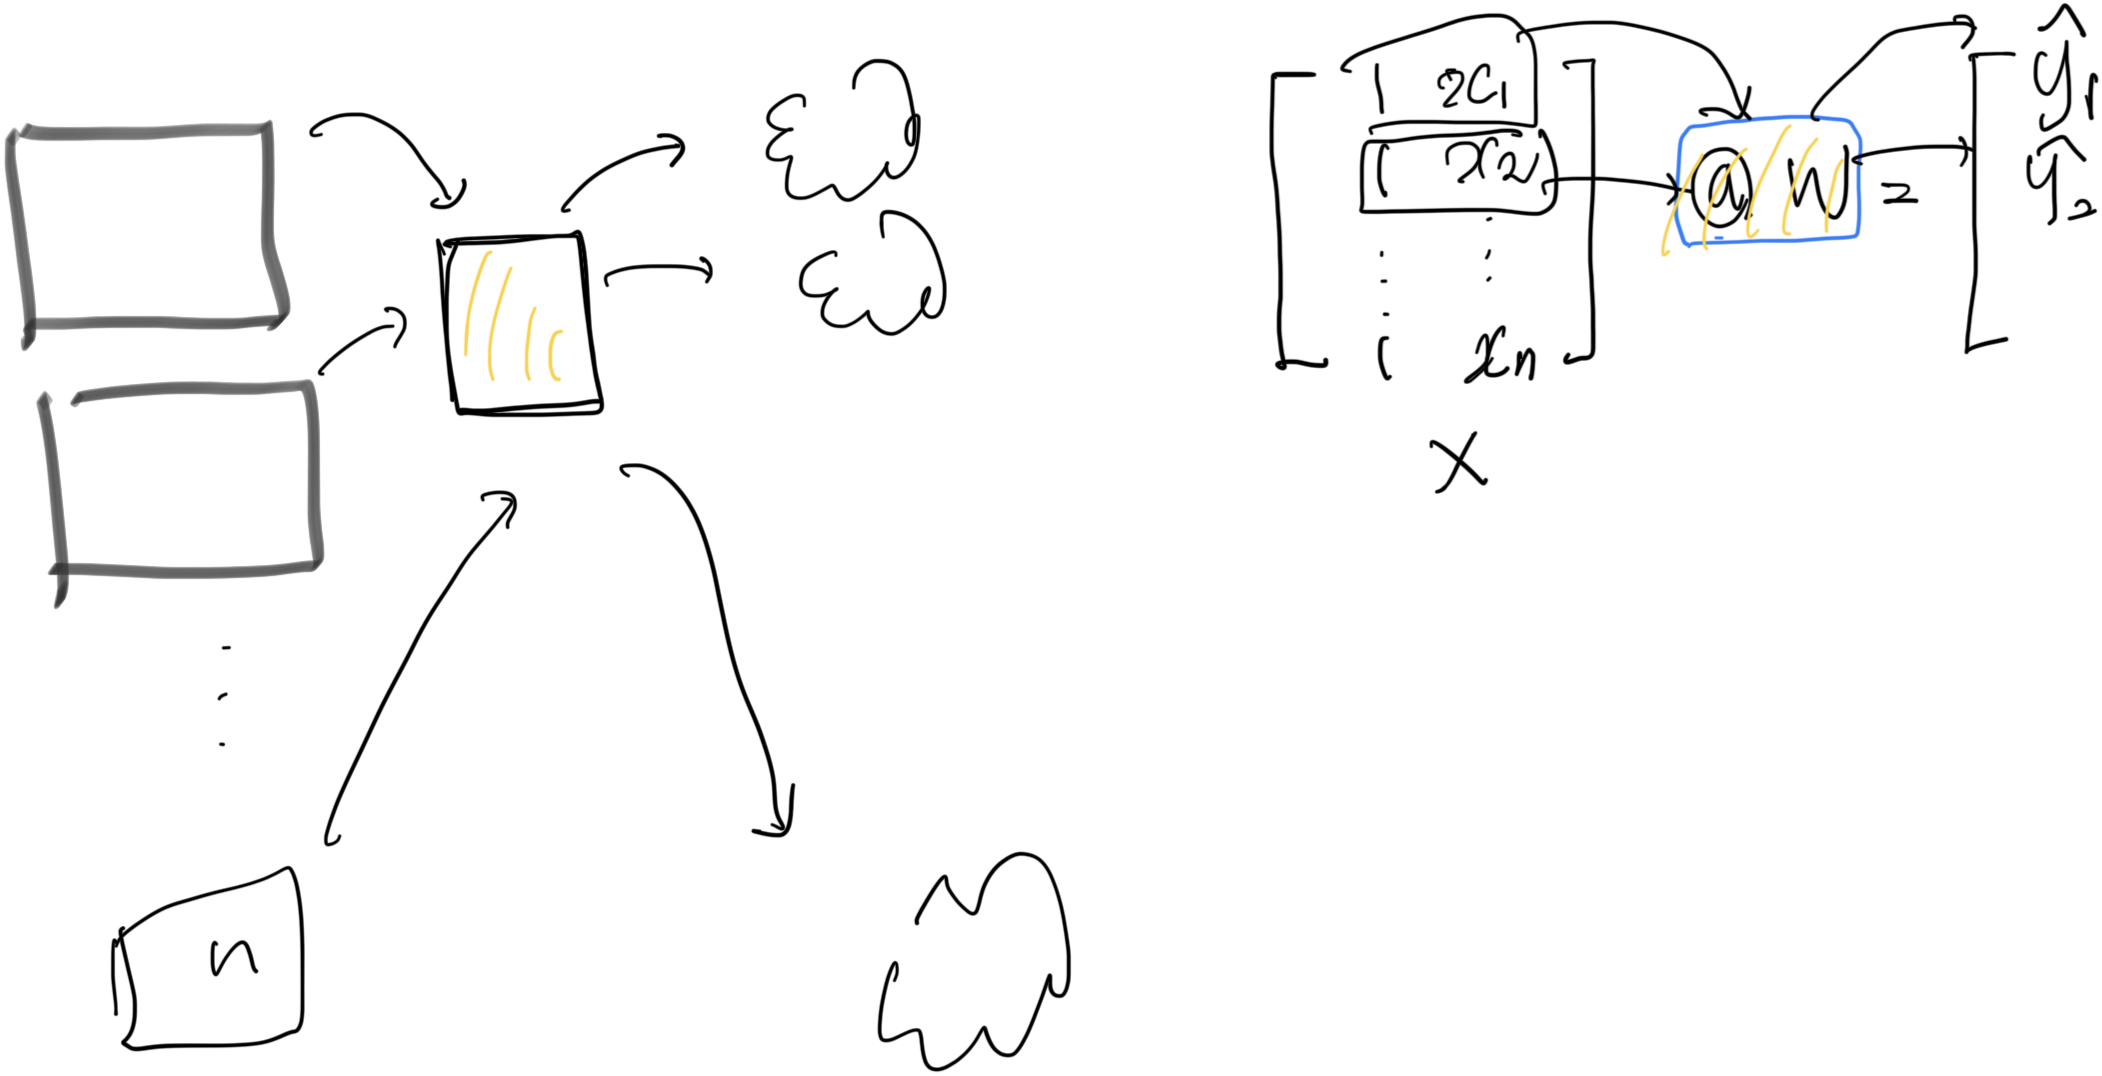

In [184]:
imgs = torch.arange(1,33).float().reshape(2,1,4,4)
conv = torch.nn.Conv2d(in_channels=1,out_channels=1,kernel_size=2,stride=1,bias=False)
conv.weight.data = conv.weight.data*0 + 1/4

In [185]:
imgs

tensor([[[[ 1.,  2.,  3.,  4.],
          [ 5.,  6.,  7.,  8.],
          [ 9., 10., 11., 12.],
          [13., 14., 15., 16.]]],


        [[[17., 18., 19., 20.],
          [21., 22., 23., 24.],
          [25., 26., 27., 28.],
          [29., 30., 31., 32.]]]])

In [186]:
conv(imgs)

tensor([[[[ 3.5000,  4.5000,  5.5000],
          [ 7.5000,  8.5000,  9.5000],
          [11.5000, 12.5000, 13.5000]]],


        [[[19.5000, 20.5000, 21.5000],
          [23.5000, 24.5000, 25.5000],
          [27.5000, 28.5000, 29.5000]]]], grad_fn=<ConvolutionBackward0>)

**(예시5) 2개의 이미지, 2개의 out_channels**

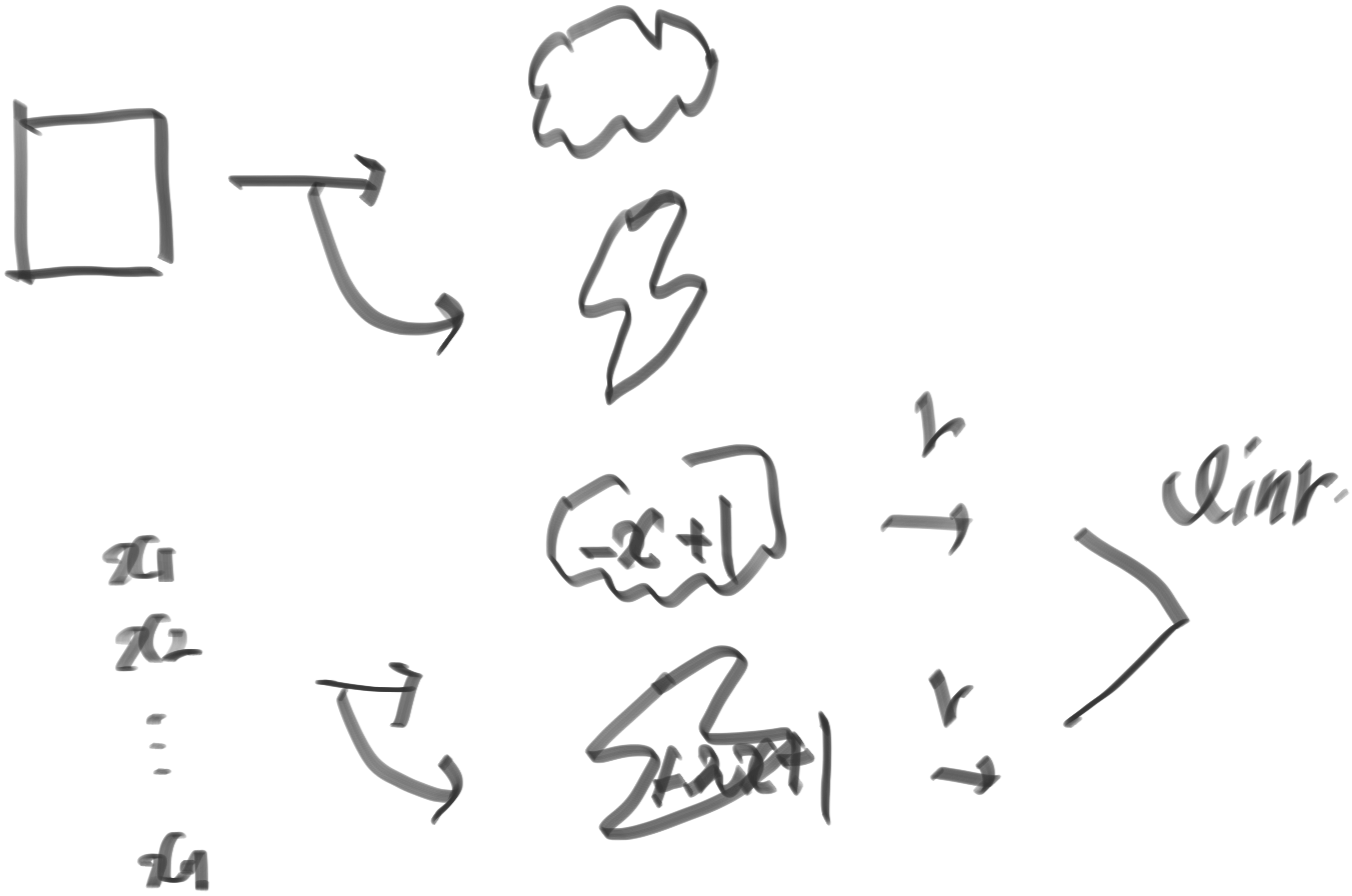

`-` 개념: (1,1,?,?) $\to$ (1,1,?,?) 의 conv를 한번 적용, 그것과 별개로 (1,1,?,?) $\to$ (1,1,?,?) 인 **다른**($\star$) conv를 적용함. (즉 하나의 observation당 2번 conv변환) 이것을 observation별로 반복

- (1,1,?,?) $\to$ (1,2,?,?) 인 경우는 (1,1,?,?) $\to$ (1,1,?,?)인 경우보다 `conv`에 포함된 파라메터 수가 2배 많음
- 그런데 (1,1,?,?) $\to$ (1,2,?,?) 인 경우와 (n,1,?,?) $\to$ (n,2,?,?)인 경우는 `conv`에 포함된 파라메터 수가 같음.
- 따라서 (n,1,?,?) $\to$ (n,2,?,?) 인 경우는 (1,1,?,?) $\to$ (1,1,?,?)인 경우보다 `conv`에 포함된 파라메터 수가 2배 많음

In [187]:
img = torch.arange(1,33).float().reshape(2,1,4,4)
conv = torch.nn.Conv2d(in_channels=1,out_channels=2,kernel_size=2,stride=1,bias=False)

In [188]:
img

tensor([[[[ 1.,  2.,  3.,  4.],
          [ 5.,  6.,  7.,  8.],
          [ 9., 10., 11., 12.],
          [13., 14., 15., 16.]]],


        [[[17., 18., 19., 20.],
          [21., 22., 23., 24.],
          [25., 26., 27., 28.],
          [29., 30., 31., 32.]]]])

In [189]:
conv.weight.data[0] = conv.weight.data[0]*0 +1/4
conv.weight.data[1] = conv.weight.data[0]*0

In [190]:
conv(img)

tensor([[[[ 3.5000,  4.5000,  5.5000],
          [ 7.5000,  8.5000,  9.5000],
          [11.5000, 12.5000, 13.5000]],

         [[ 0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000]]],


        [[[19.5000, 20.5000, 21.5000],
          [23.5000, 24.5000, 25.5000],
          [27.5000, 28.5000, 29.5000]],

         [[ 0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000]]]], grad_fn=<ConvolutionBackward0>)

In [191]:
conv(img)

tensor([[[[ 3.5000,  4.5000,  5.5000],
          [ 7.5000,  8.5000,  9.5000],
          [11.5000, 12.5000, 13.5000]],

         [[ 0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000]]],


        [[[19.5000, 20.5000, 21.5000],
          [23.5000, 24.5000, 25.5000],
          [27.5000, 28.5000, 29.5000]],

         [[ 0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000]]]], grad_fn=<ConvolutionBackward0>)